Olá, **Brunno**!

O meu nome é **César Malaguti** e sou o revisor do seu projeto. Quando identificar um erro pela primeira vez, apenas vou apontá-lo para que você mesmo possa encontrá-lo e corrigi-lo. Ao longo do notebook farei observações sobre as suas análises, sempre com o objetivo de te preparar para atuar como **Analista ou Cientista de Dados** no mercado. **Por favor, não mova, modifique ou exclua meus comentários.**

Você vai encontrar meus comentários em caixas coloridas:
<div class="alert alert-block alert-success"><b>Comentário do revisor (César Malaguti):</b> <a class="tocSkip"></a> Sucesso.</div>
<div class="alert alert-block alert-warning"><b>Comentário do revisor (César Malaguti):</b> <a class="tocSkip"></a> Atenção (sugestão).</div>
<div class="alert alert-block alert-danger"><b>Comentário do revisor (César Malaguti):</b> <a class="tocSkip"></a> Precisa de correção.</div>

Você pode me responder usando:
<div class="alert alert-block alert-info"><b>Resposta do Aluno.</b> <a class="tocSkip"></a></div>


<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

<b>Comentário geral:</b> Brunno, parabéns, **projeto APROVADO!**

O modelo final atinge a meta com folga: **F1 de 0,6108 no teste**, acima do mínimo de 0,59, com AUC-ROC de 0,8557. E o caminho até lá está bem documentado: um modelo de referência sem tratar o desbalanceamento, duas abordagens de correção (peso das classes e upsampling) comparadas na validação, ajuste de hiperparâmetros e só no fim o teste. A divisão em treino, validação e teste e a padronização ajustada só no treino estão corretas.

Deixei dois amarelos: o principal é testar pelo menos mais um tipo de modelo, como o enunciado pede.
</div>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

In [27]:
# Carregar o conjunto de dados
data = pd.read_csv('/datasets/Churn.csv')

# Visualizar as primeiras linhas
display(data.head())

# Verificar o tamanho do conjunto de dados
print('Dimensões do dataset:', data.shape)

# Verificar informações gerais, tipos de dados e valores ausentes
data.info()

# Verificar estatísticas descritivas
display(data.describe())

# Verificar valores ausentes
print('\nValores ausentes por coluna:')
print(data.isna().sum())

# Verificar registros duplicados
print('\nNúmero de registros duplicados:')
print(data.duplicated().sum())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


Dimensões do dataset: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,9091.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,4.997690,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.894723,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,2.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



Valores ausentes por coluna:
RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

Número de registros duplicados:
0


In [28]:
# Preencher os valores ausentes de Tenure com a mediana
data['Tenure'] = data['Tenure'].fillna(data['Tenure'].median())

# Remover colunas que não são necessárias para o modelo
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Transformar as características categóricas
data_ohe = pd.get_dummies(data, drop_first=True)

# Verificar o resultado
print(data_ohe.head())
print(data_ohe.isna().sum())

   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42     2.0       0.00              1          1   
1          608   41     1.0   83807.86              1          0   
2          502   42     8.0  159660.80              3          1   
3          699   39     1.0       0.00              2          0   
4          850   43     2.0  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0               1        101348.88       1                  0   
1               1        112542.58       0                  0   
2               0        113931.57       1                  0   
3               0         93826.63       0                  0   
4               1         79084.10       0                  0   

   Geography_Spain  Gender_Male  
0                0            0  
1                1            0  
2                0            0  
3                0            0  
4                1            

O conjunto de dados possui 10.000 registros. Na análise inicial, foram encontrados 909 valores ausentes na coluna Tenure e nenhum registro duplicado. Os valores ausentes foram preenchidos com a mediana da coluna e as colunas RowNumber, CustomerId e Surname foram removidas por serem informações de identificação que não são necessárias para o treinamento do modelo. As características categóricas Geography e Gender foram transformadas utilizando One-Hot Encoding (OHE) com drop_first=True. Após o tratamento, não existem valores ausentes e os dados estão preparados para a etapa de modelagem.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

**A preparação está bem resolvida e explicada**: os 909 ausentes de `Tenure`, a remoção de `RowNumber`, `CustomerId` e `Surname` (identificadores que não dizem nada sobre o comportamento do cliente e só atrapalhariam o modelo) e o One-Hot Encoding com `drop_first=True`, que evita colunas redundantes.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Um detalhe de rigor, **sem impacto relevante no resultado**: a mediana de `Tenure` foi calculada com a base inteira, antes da divisão. O ideal é calculá-la só no treino e usar esse valor para preencher validação e teste, para que nenhuma informação dos conjuntos de avaliação entre no modelo. Com 909 ausentes e uma mediana estável, o efeito aqui é pequeno, mas o hábito vale para os próximos projetos.
</div>

0    0.7963
1    0.2037
Name: Exited, dtype: float64


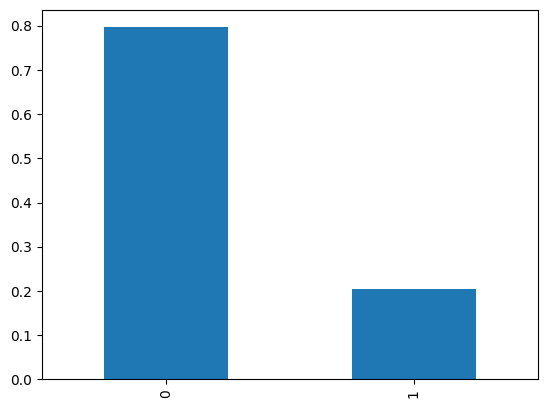

In [29]:
# Verificar o balanceamento das classes
class_frequency = data_ohe['Exited'].value_counts(normalize=True)

print(class_frequency)

class_frequency.plot(kind='bar')
plt.show()

In [30]:
# Separar as características e o alvo
features = data_ohe.drop('Exited', axis=1)
target = data_ohe['Exited']

# Separar os dados em treino e conjunto restante
features_train, features_valid_test, target_train, target_valid_test = train_test_split(
    features,
    target,
    test_size=0.4,
    random_state=12345
)

# Dividir o conjunto restante em validação e teste
features_valid, features_test, target_valid, target_test = train_test_split(
    features_valid_test,
    target_valid_test,
    test_size=0.5,
    random_state=12345
)

print('Treino:', features_train.shape)
print('Validação:', features_valid.shape)
print('Teste:', features_test.shape)

Treino: (6000, 11)
Validação: (2000, 11)
Teste: (2000, 11)


In [31]:

# Criar cópias dos conjuntos
features_train = features_train.copy()
features_valid = features_valid.copy()
features_test = features_test.copy()

# Selecionar as características numéricas
numeric = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary'
]

# Padronizar as características numéricas
scaler = StandardScaler()
scaler.fit(features_train[numeric])

features_train[numeric] = scaler.transform(features_train[numeric])
features_valid[numeric] = scaler.transform(features_valid[numeric])
features_test[numeric] = scaler.transform(features_test[numeric])

print(features_train.head())

      CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
7479    -0.886751 -0.373192  1.082277  1.232271      -0.891560          1   
3411     0.608663 -0.183385  1.082277  0.600563      -0.891560          0   
6027     2.052152  0.480939 -0.737696  1.027098       0.830152          0   
1247    -1.457915 -1.417129  0.354288 -1.233163       0.830152          1   
3716     0.130961 -1.132419 -1.101690  1.140475      -0.891560          0   

      IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
7479               0        -0.187705                  0                1   
3411               0        -0.333945                  0                0   
6027               1         1.503095                  1                0   
1247               0        -1.071061                  0                0   
3716               0         1.524268                  1                0   

      Gender_Male  
7479            1  
3411            0  
6027          

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

**A padronização está feita do jeito certo**: o `StandardScaler` aprende a média e o desvio só com o treino e depois é aplicado aos três conjuntos. E você padronizou apenas as colunas numéricas contínuas, deixando as binárias como estão.
</div>

In [32]:
# Treinar o modelo sem considerar o desbalanceamento
model = RandomForestClassifier(
    random_state=12345,
    n_estimators=100
)

model.fit(features_train, target_train)

# Fazer previsões no conjunto de validação
predicted_valid = model.predict(features_valid)

# Calcular F1
f1 = f1_score(target_valid, predicted_valid)

print('F1:', f1)

F1: 0.5769805680119582


In [33]:
# Calcular as probabilidades da classe positiva
probabilities_valid = model.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]

# Calcular AUC-ROC
auc_roc = roc_auc_score(target_valid, probabilities_one_valid)

print('AUC-ROC:', auc_roc)

AUC-ROC: 0.840733672475638


A análise da variável alvo Exited mostrou que as classes estão desbalanceadas. 
Aproximadamente 79,63% dos clientes pertencem à classe 0 e 20,37% à classe 1 já o modelo Random Forest foi treinado inicialmente sem considerar esse desbalanceamento. No conjunto de validação, o modelo apresentou F1 de 0,5770 e AUC-ROC de 0,8407. O valor de F1 ficou abaixo da meta mínima de 0,59 estabelecida para o projeto. Portanto, será necessário trabalhar o desequilíbrio das classes e comparar diferentes abordagens para tentar melhorar a qualidade do modelo.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

**Começar por um modelo sem tratar o desbalanceamento** é o que dá sentido a todo o resto: com F1 de 0,577, fica claro que o modelo não atinge a meta sozinho e que as correções seguintes fazem diferença.
</div>

In [34]:
# Treinar modelos com ajuste do peso das classes
best_model = None
best_result = 0
best_depth = 0

for depth in range(1, 16):
    model = RandomForestClassifier(
        random_state=12345,
        n_estimators=100,
        max_depth=depth,
        class_weight='balanced'
    )

    model.fit(features_train, target_train)
    predicted_valid = model.predict(features_valid)

    result = f1_score(target_valid, predicted_valid)

    if result > best_result:
        best_model = model
        best_result = result
        best_depth = depth

print('Melhor F1:', best_result)
print('Melhor profundidade:', best_depth)

Melhor F1: 0.6264073694984648
Melhor profundidade: 6


In [35]:
probabilities_valid = best_model.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]

auc_roc = roc_auc_score(target_valid, probabilities_one_valid)

print('AUC-ROC:', auc_roc)

AUC-ROC: 0.8532050157574145


In [36]:
# Função para aumentar a quantidade de exemplos da classe minoritária
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat(
        [features_zeros] + [features_ones] * repeat
    )
    target_upsampled = pd.concat(
        [target_zeros] + [target_ones] * repeat
    )

    features_upsampled, target_upsampled = shuffle(
        features_upsampled,
        target_upsampled,
        random_state=12345
    )

    return features_upsampled, target_upsampled


# Aplicar o upsampling
features_upsampled, target_upsampled = upsample(
    features_train,
    target_train,
    4
)

print(features_upsampled.shape)
print(target_upsampled.value_counts(normalize=True))

(9588, 11)
0    0.501043
1    0.498957
Name: Exited, dtype: float64


In [37]:
best_model_upsampled = None
best_result_upsampled = 0
best_depth_upsampled = 0

for depth in range(1, 16):
    model = RandomForestClassifier(
        random_state=12345,
        n_estimators=100,
        max_depth=depth
    )

    model.fit(features_upsampled, target_upsampled)
    predicted_valid = model.predict(features_valid)

    result = f1_score(target_valid, predicted_valid)

    if result > best_result_upsampled:
        best_model_upsampled = model
        best_result_upsampled = result
        best_depth_upsampled = depth

print('Melhor F1 com upsampling:', best_result_upsampled)
print('Melhor profundidade:', best_depth_upsampled)

Melhor F1 com upsampling: 0.6275346851654217
Melhor profundidade: 9


In [38]:
probabilities_valid = best_model_upsampled.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]

auc_roc_upsampled = roc_auc_score(
    target_valid,
    probabilities_one_valid
)

print('AUC-ROC com upsampling:', auc_roc_upsampled)

AUC-ROC com upsampling: 0.8526772482291812


O upsampling apresentou o maior valor de F1 entre as abordagens testadas. Para tentar melhorar o desempenho do modelo, serão testados diferentes valores para o número de árvores (n_estimators) e para a profundidade máxima (max_depth) da Random Forest. O melhor modelo será escolhido com base no F1 obtido no conjunto de validação.

In [41]:
best_model = None
best_f1 = 0
best_depth = 0
best_est = 0

for est in [50, 100, 150]:
    for depth in range(5, 16):
        model = RandomForestClassifier(
            random_state=12345,
            n_estimators=est,
            max_depth=depth
        )

        model.fit(features_upsampled, target_upsampled)

        predicted_valid = model.predict(features_valid)

        f1 = f1_score(target_valid, predicted_valid)

        if f1 > best_f1:
            best_model = model
            best_f1 = f1
            best_depth = depth
            best_est = est

print('Melhor F1:', best_f1)
print('Melhor profundidade:', best_depth)
print('Melhor número de árvores:', best_est)

Melhor F1: 0.6275346851654217
Melhor profundidade: 9
Melhor número de árvores: 100


Após testar diferentes combinações de parâmetros, o melhor resultado foi obtido com 100 árvores e profundidade máxima igual a 9. O modelo apresentou F1 de 0,6275 no conjunto de validação. A seguir, será calculado também o AUC-ROC desse modelo.

In [42]:
probabilities_valid = best_model.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]

auc_roc = roc_auc_score(target_valid, probabilities_one_valid)

print('AUC-ROC:', auc_roc)

AUC-ROC: 0.8526772482291812


Foram utilizadas duas abordagens para corrigir o desbalanceamento das classes: ajuste do peso das classes e upsampling.
Com o ajuste do peso das classes, o modelo alcançou F1 de 0,6264 e AUC-ROC de 0,8532. Com o upsampling, o melhor modelo alcançou F1 de 0,6275 e AUC-ROC de 0,8527.
Também foram testadas diferentes combinações de número de árvores e profundidade máxima. O melhor resultado com upsampling foi obtido com 100 árvores e profundidade máxima igual a 9.
Comparando os resultados, o upsampling apresentou o maior F1 e foi escolhido como o melhor modelo. Além disso, o resultado superou o valor mínimo de F1 de 0,59 estabelecido para o projeto.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

**A comparação entre as abordagens é justa e a escolha está justificada**: as duas foram avaliadas com a mesma busca de profundidade, no mesmo conjunto de validação, pela métrica do projeto (F1). E o teste só foi usado uma vez, no modelo final, que é o que garante que o 0,6108 é uma estimativa honesta.
</div>

In [43]:
# Fazer previsões no conjunto de teste
predicted_test = best_model.predict(features_test)

# Calcular F1
f1_test = f1_score(target_test, predicted_test)

# Calcular as probabilidades da classe positiva
probabilities_test = best_model.predict_proba(features_test)
probabilities_one_test = probabilities_test[:, 1]

# Calcular AUC-ROC
auc_roc_test = roc_auc_score(target_test, probabilities_one_test)

print('F1 no conjunto de teste:', f1_test)
print('AUC-ROC no conjunto de teste:', auc_roc_test)

F1 no conjunto de teste: 0.6107660455486542
AUC-ROC no conjunto de teste: 0.8556960203636494


No conjunto de teste, o modelo apresentou F1 de 0,6108 e AUC-ROC de 0,8557.
O valor de F1 ficou acima da meta mínima de 0,59 estabelecida para o projeto. Além disso, o AUC-ROC indica que o modelo possui uma boa capacidade de distinguir entre clientes que permanecem no banco e clientes que saem.
Comparando com o conjunto de validação, em que o F1 foi de 0,6275, houve uma pequena redução no teste final, mas o desempenho permaneceu acima da meta estabelecida.

Neste projeto, foi desenvolvido um modelo para prever a saída de clientes do Beta Bank.
Inicialmente, os dados foram preparados por meio do tratamento dos valores ausentes, remoção de colunas desnecessárias e transformação das características categóricas com One-Hot Encoding.
A análise da variável alvo mostrou um desbalanceamento entre as classes, com aproximadamente 80% dos clientes na classe 0 e 20% na classe 1. Sem tratar esse desbalanceamento, o modelo apresentou F1 de 0,5770.
Para melhorar o desempenho, foram testadas duas abordagens: ajuste do peso das classes e upsampling. O upsampling apresentou o maior F1 no conjunto de validação, chegando a 0,6275. A melhor configuração encontrada para a Random Forest utilizou 100 árvores e profundidade máxima igual a 9.
No teste final, o modelo alcançou F1 de 0,6108 e AUC-ROC de 0,8557. Portanto, o modelo atingiu a meta de F1 mínima de 0,59 estabelecida para o projeto.

<div class="alert alert-block alert-warning">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

**Falta comparar tipos diferentes de modelo.** O enunciado pede para treinar modelos diferentes e encontrar o melhor, e o notebook testa só o Random Forest (com várias configurações). Você até importou a Regressão Logística e a Árvore de Decisão na primeira célula. Treine as duas com a mesma correção de desbalanceamento e mostre uma tabela com o F1 e a AUC-ROC de cada uma na validação. Assim a escolha do Random Forest deixa de ser um ponto de partida e vira uma conclusão.

E, como o tema do projeto é engenharia de atributos, uma ideia **opcional**: criar uma variável nova e ver se ela ajuda, por exemplo um indicador de saldo zerado (`Balance == 0`), que separa um grupo grande de clientes.
</div>